In [108]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier

# Load Data

In [109]:
df =pd.read_csv("/kaggle/input/datasets/manukulamkombil/machinehack-financial-risk-prediction/Train.csv")


In [110]:
df

,City,Location_Score,Internal_Audit_Score,External_Audit_Score,Fin_Score,Loss_score,Past_Results,IsUnderRisk
0,2,8.032,14,8,3,6,0,1
1,31,77.730,8,3,3,8,1,0
2,40,59.203,3,12,11,3,0,1
3,12,73.080,4,5,7,6,0,0
4,4,15.666,13,15,6,7,2,1
...,...,...,...,...,...,...,...,...
538,16,74.017,7,4,5,7,1,0
539,2,70.460,7,5,6,4,0,0
540,1,79.243,7,5,3,8,1,0
541,40,69.140,7,8,4,5,1,1


# Exploratory Data Analysis

## **Target Distribution**

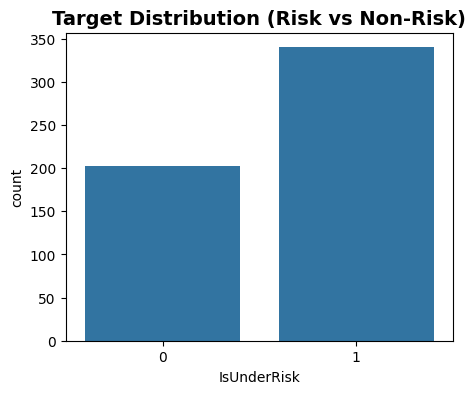

IsUnderRisk
1    0.626151
0    0.373849
Name: proportion, dtype: float64


In [93]:

plt.figure(figsize=(5,4))
sns.countplot(data=df, x='IsUnderRisk')

plt.title('Target Distribution (Risk vs Non-Risk)', fontsize=14, weight='bold')
plt.show()

print(df['IsUnderRisk'].value_counts(normalize=True))

### **Target Distribution Analysis (Risk vs Non-Risk)**

**1. Objective**
The purpose of this analysis is to evaluate the **distribution of the target variable** (`IsUnderRisk`) and understand whether the dataset is **balanced or imbalanced**, which directly impacts modeling strategy.

---

**2. Distribution Overview**

From the dataset:

* **Risk (1): ~62.6%**
* **Non-Risk (0): ~37.4%**

This indicates that the dataset is **moderately imbalanced**, with a higher proportion of **risk cases**.

**Insight:**
The dataset is **not severely imbalanced**, but the dominance of **risk cases** may bias models toward predicting the majority class.

---

**3. Distribution Behavior**

* The difference between classes is noticeable but not extreme
* Both classes still have **sufficient representation**

**Insight:**
Standard classification models can still perform well, but **evaluation metrics must go beyond accuracy**.

---

**4. Risk Interpretation**

From a modeling perspective:

* A naive model could achieve ~62% accuracy by predicting all observations as **risk**
* This makes **accuracy alone misleading**

**Key Point:**
Model performance should be evaluated using **precision, recall, F1-score, and ROC-AUC**, rather than accuracy.

---

**5. Modeling Implications**

* No immediate need for aggressive resampling (e.g., SMOTE or undersampling)
* However, **class imbalance awareness** is still required

**Insight:**
Using techniques such as:

* **class weighting**
* **threshold tuning**

can improve model robustness.

---

**6. Key Takeaways**

* The dataset shows a **moderate class imbalance**
* **Risk cases dominate (~62%)**, but not critically
* **Accuracy is not a reliable metric**
* The problem remains suitable for **standard supervised learning approaches**

---

**Analyst Note**

Even moderate imbalance can distort model behavior. A well-performing model should **balance detection of risk cases while minimizing false positives**, rather than optimizing for overall accuracy alone.


## **Continuous and Categorical Features**

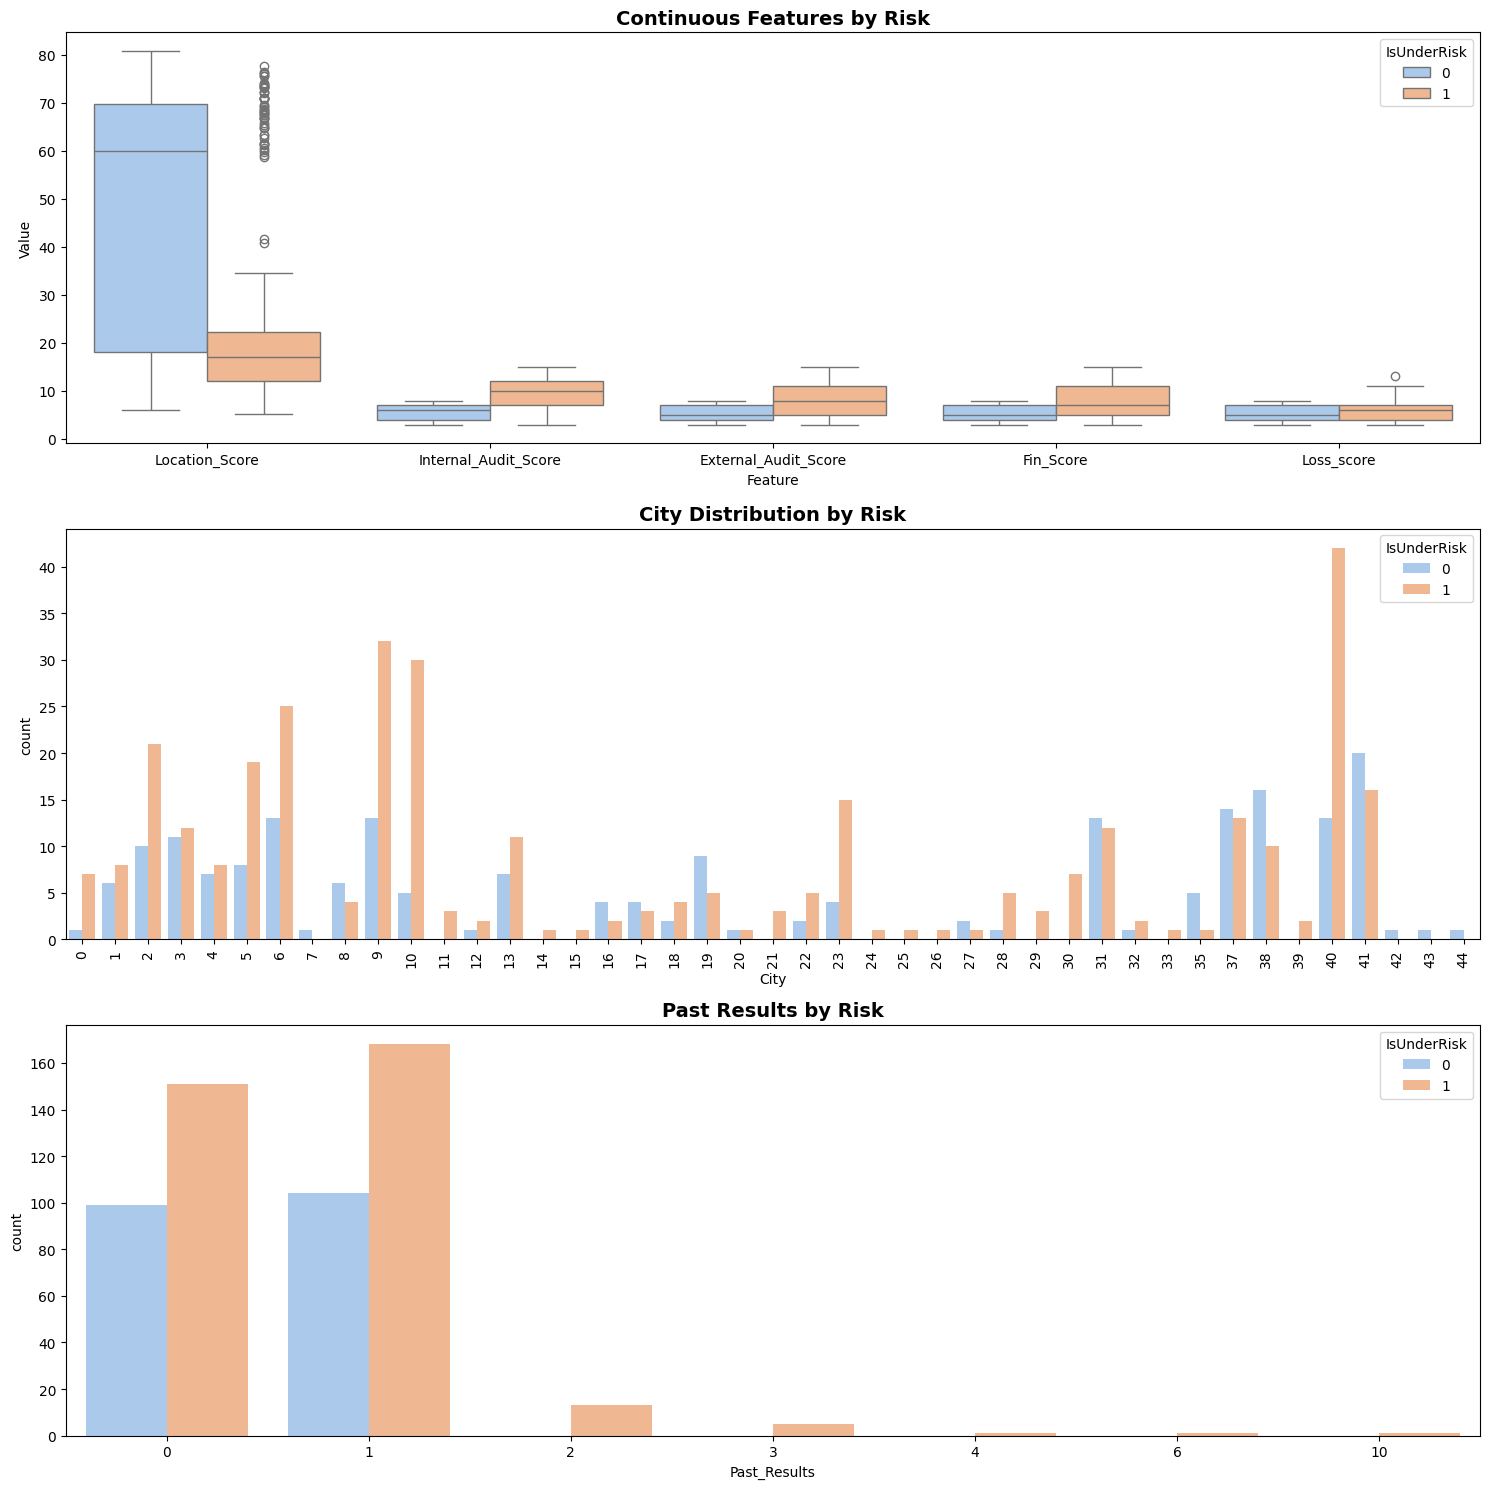

In [97]:
fig, axs = plt.subplots(3, 1, figsize=(15, 15))
df_melt = df.melt(
    id_vars='IsUnderRisk',
    value_vars=continuous,
    var_name='Feature',
    value_name='Value'
)

sns.boxplot(
    data=df_melt,
    x='Feature',
    y='Value',
    hue='IsUnderRisk',
    palette='pastel',
    ax=axs[0]
)

sns.countplot(
    data=df,
    x='City',
    hue='IsUnderRisk',
    palette='pastel',
    ax=axs[1]
)

sns.countplot(
    data=df,
    x='Past_Results',
    hue='IsUnderRisk',
    palette='pastel',
    ax=axs[2]
)

axs[0].set_title('Continuous Features by Risk', fontsize=14, weight='bold')
axs[1].set_title('City Distribution by Risk', fontsize=14, weight='bold')
axs[2].set_title('Past Results by Risk', fontsize=14, weight='bold')

axs[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

### Analysis **Risk Analysis Based on Continuous and Categorical Features**

**1. Objective**
The purpose of this analysis is to understand how different **features relate to risk** (`IsUnderRisk`) and identify patterns that distinguish **risky vs non-risky entities**.

The dataset contains **structured indicators** including **location score, audit scores, financial score, loss score, and historical results**.

---

**2. Continuous Feature Analysis**

The comparison between **risk (1)** and **non-risk (0)** reveals distinct patterns:

* **Location_Score**

  * **Non-risk** observations have significantly higher values
  * **Risk** observations are concentrated at lower values

  **Insight:**
  Higher **Location_Score** is strongly associated with **lower risk**, making it one of the most important protective features.

---

* **Internal_Audit_Score**

  * **Risk** observations tend to have higher values

  **Insight:**
  Higher **internal audit scores** likely reflect **detected issues**, which correlates with increased risk.

---

* **External_Audit_Score**

  * Similar pattern to internal audit score, with **risk showing higher values**

  **Insight:**
  **External audits reinforce internal findings**, indicating consistency in identifying high-risk entities.

---

* **Fin_Score**

  * **Risk and non-risk distributions overlap significantly**

  **Insight:**
  **Financial score alone is not a strong discriminator**, suggesting limited standalone predictive power.

---

* **Loss_score**

  * **Risk observations are slightly higher**, but with overlap

  **Insight:**
  **Loss_score contributes to risk**, but requires combination with other features to be effective.

---

**3. Categorical Feature Analysis**

* **City**

  * Distribution varies across cities, with some showing **higher counts of risk cases**

  **Insight:**
  Certain **locations may have higher exposure to risk**, but raw counts are misleading without normalization.

---

* **Past_Results**

  * **Risk frequency increases with higher values**

  **Insight:**
  **Historical performance is a strong behavioral predictor**, showing a clear increasing risk trend.

---

**4. Distribution Behavior**

Across most features:

* There is **significant overlap** between risk and non-risk groups
* No clear separation exists at the **single-feature level**

**Insight:**
The problem is **not linearly separable**, indicating that **feature interactions are required**.

---

**5. Risk Interpretation**

From a **risk perspective**:

* Risk is associated with:

  * **Lower Location_Score**
  * **Higher audit scores**
  * **Worse historical results**

* However:

  * Most features individually show **overlapping distributions**

**Key Point:**
Risk is driven by a **combination of factors**, not by any single variable.

---

**6. Key Takeaways**

* **Location_Score** shows a **strong negative relationship** with risk
* **Audit scores** are **positively associated** with risk
* **Past_Results** provides a **strong behavioral signal**
* **Feature overlap exists**, indicating weak standalone predictors
* The dataset represents a **structured risk scoring problem**, not simple anomaly detection

---


## **Feature Distribution by Risk Segment**

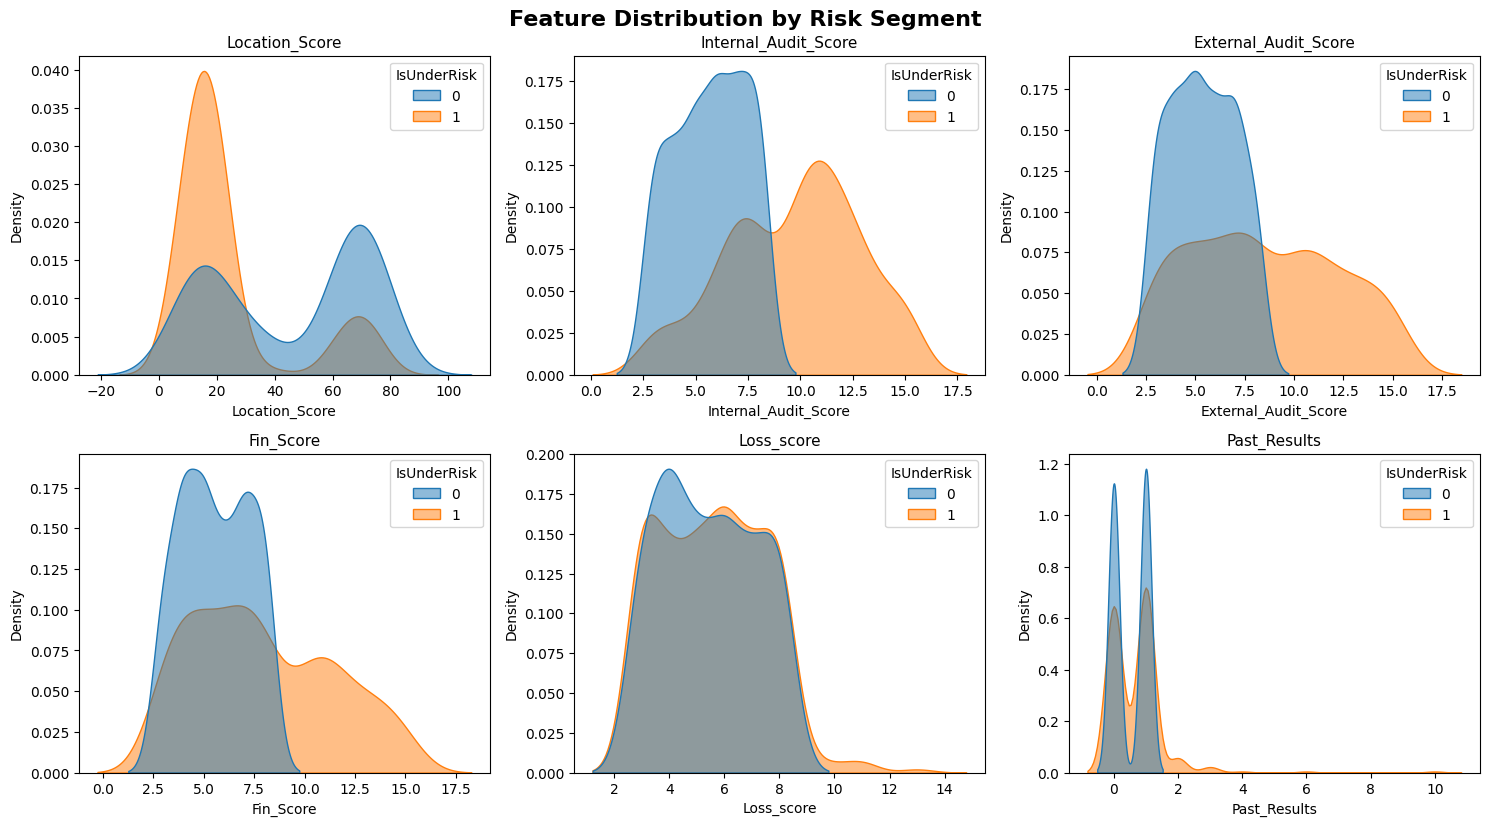

In [98]:
cols = [
    'Location_Score',
    'Internal_Audit_Score',
    'External_Audit_Score',
    'Fin_Score',
    'Loss_score',
    'Past_Results'
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for i, col in enumerate(cols):
    ax = axes[i//3, i%3]
    
    sns.kdeplot(
        data=df,
        x=col,
        hue='IsUnderRisk',
        fill=True,
        common_norm=False,
        alpha=0.5,
        ax=ax
    )
    
    ax.set_title(col, fontsize=11)

for j in range(len(cols), 9):
    fig.delaxes(axes[j//3][j%3])

plt.suptitle('Feature Distribution by Risk Segment', fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

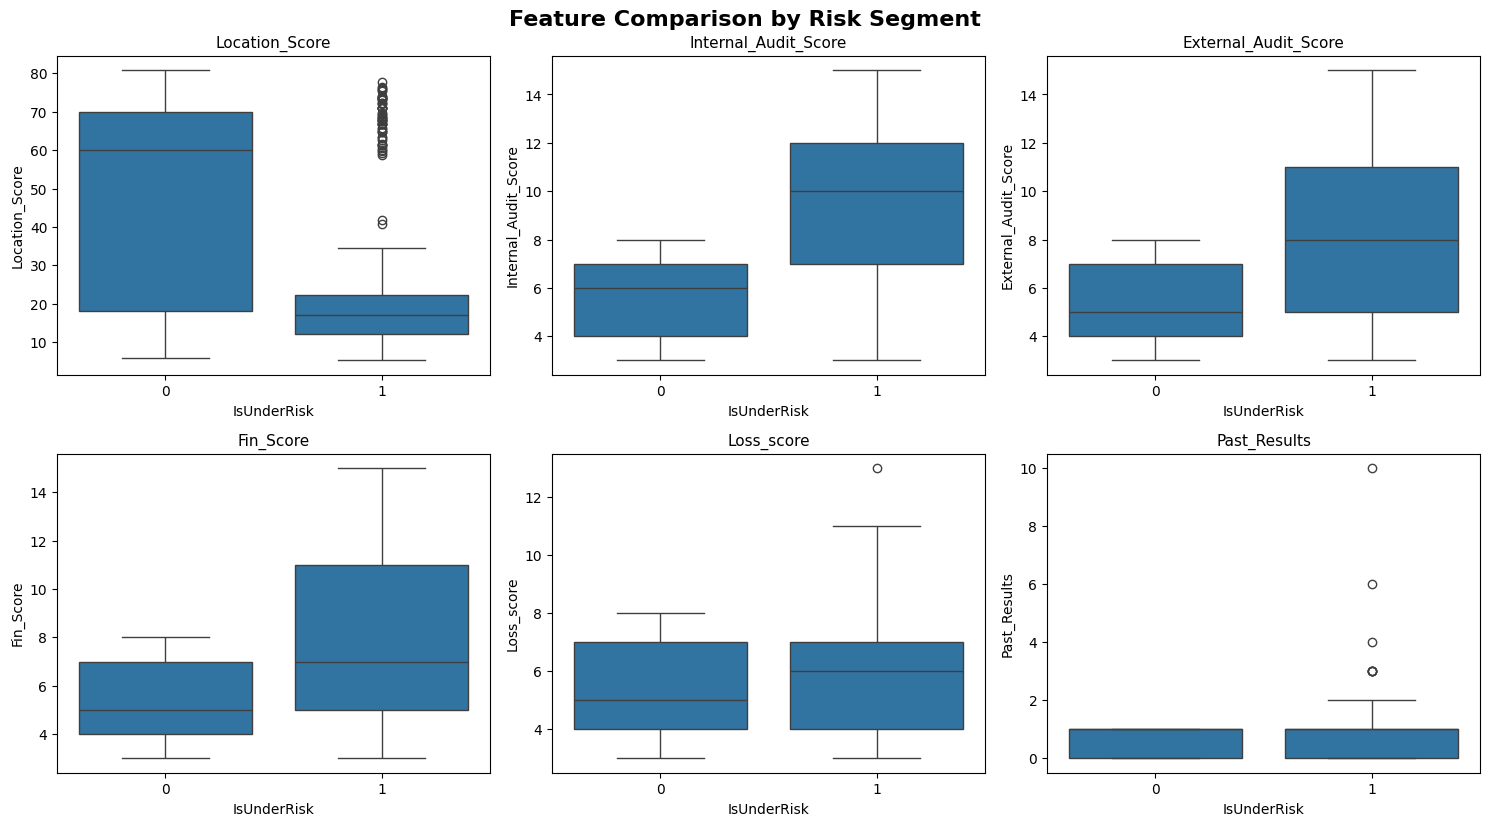

In [99]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for i, col in enumerate(cols):
    ax = axes[i//3, i%3]
    
    sns.boxplot(
        data=df,
        x='IsUnderRisk',
        y=col,
        ax=ax
    )
    
    ax.set_title(col, fontsize=11)

# hapus subplot kosong
for j in range(len(cols), 9):
    fig.delaxes(axes[j//3][j%3])

plt.suptitle('Feature Comparison by Risk Segment', fontsize=16, weight='bold')
plt.tight_layout()
plt.show()


---

### **Feature Distribution and Comparison by Risk Segment**

**1. Objective**
The purpose of this analysis is to combine **distribution patterns (KDE)** and **statistical summaries (boxplots)** to identify how features differentiate **risk (1)** and **non-risk (0)** observations.

---

**2. Location_Score**

* **KDE Insight:**

  * Clear separation between **risk (low values)** and **non-risk (high values)**
* **Boxplot Insight:**

  * Median of **non-risk is significantly higher**
  * Risk group has **lower central tendency and tighter range**

**Insight:**
**Location_Score is the strongest discriminator**, with a clear negative relationship to risk.

---

**3. Internal_Audit_Score**

* **KDE Insight:**

  * Risk distribution is shifted toward **higher values**
* **Boxplot Insight:**

  * Median of **risk is clearly higher**
  * Wider spread in risk group

**Insight:**
Higher **Internal_Audit_Score reflects detected issues**, making it a strong **positive risk indicator**.

---

**4. External_Audit_Score**

* **KDE Insight:**

  * Similar upward shift for **risk group**
* **Boxplot Insight:**

  * Risk median is higher with broader distribution

**Insight:**
**External audit confirms internal audit findings**, strengthening its role as a **consistent risk signal**.

---

**5. Fin_Score**

* **KDE Insight:**

  * Significant overlap between risk and non-risk
* **Boxplot Insight:**

  * Slightly higher median for risk, but not substantial

**Insight:**
**Fin_Score has limited standalone predictive power**, as separation is weak.

---

**6. Loss_score**

* **KDE Insight:**

  * Heavy overlap between both groups
* **Boxplot Insight:**

  * Slightly higher median for risk with some upper outliers

**Insight:**
**Loss_score alone is insufficient**, but may become useful when combined with other features.

---

**7. Past_Results**

* **KDE Insight:**

  * Risk group shows a **long tail toward higher values**
* **Boxplot Insight:**

  * Most values concentrated at **0–1**, but risk has **extreme outliers**

**Insight:**
**Past_Results captures behavioral anomalies**, where extreme values strongly indicate risk.

---

**8. Distribution Behavior**

Across features:

* Some features show **clear separation (Location_Score)**
* Others show **shifted distributions (Audit Scores)**
* Several show **heavy overlap (Fin_Score, Loss_score)**

**Insight:**
The dataset contains a mix of **strong, moderate, and weak predictors**.

---

**9. Risk Interpretation**

From combined analysis:

* Strong indicators:

  * **Location_Score (negative correlation)**
  * **Audit Scores (positive correlation)**
  * **Past_Results (behavioral signal)**

* Weak indicators:

  * **Fin_Score**
  * **Loss_score (standalone)**

**Key Point:**
Risk is best explained through **combined feature effects**, not individual variables.

---

**10. Key Takeaways**

* **Location_Score provides clear separation between classes**
* **Audit-related features consistently increase with risk**
* **Past_Results highlights extreme behavioral risk**
* **Overlap in several features indicates non-linear relationships**
* The dataset is suitable for **tree-based or ensemble models**

---

**Analyst Note**

Combining **distribution analysis (KDE)** and **statistical summaries (boxplots)** reveals that while some features clearly separate risk, others require **interaction and transformation**. This confirms that **feature engineering and non-linear modeling approaches** are essential for optimal performance.


## **Loss Score**

In [100]:
risk_mean = df.groupby('IsUnderRisk').mean().T
risk_mean['diff'] = risk_mean[1] - risk_mean[0]
risk_mean = risk_mean.sort_values('diff', ascending=False)

print(risk_mean)

IsUnderRisk                   0          1       diff
Internal_Audit_Score   5.679803   9.688235   4.008432
External_Audit_Score   5.384236   8.488235   3.103999
Fin_Score              5.566502   7.929412   2.362909
Loss_score             5.423645   5.594118   0.170472
Past_Results           0.512315   0.673529   0.161214
City                  21.241379  18.582353  -2.659026
Location_Score        45.901695  24.114062 -21.787633


/tmp/ipykernel_55/2279656850.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_bucket = df_.groupby('loss_bin')['IsUnderRisk'].mean()


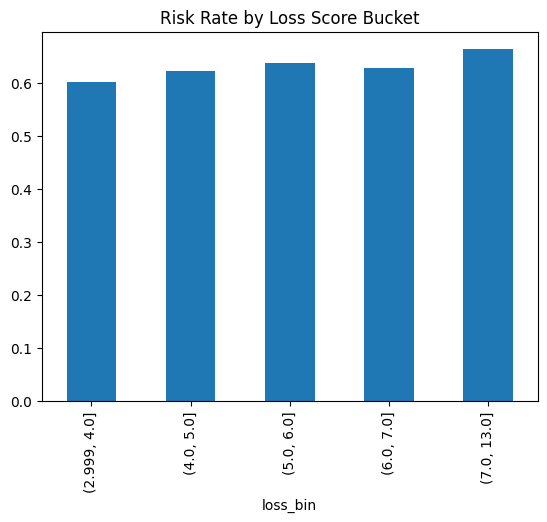

In [101]:
df_=df.copy()
df_['loss_bin'] = pd.qcut(df['Loss_score'], 5)

risk_bucket = df_.groupby('loss_bin')['IsUnderRisk'].mean()

risk_bucket.plot(kind='bar', title='Risk Rate by Loss Score Bucket')
plt.show()

### **Feature Importance Approximation and Risk Bucket Analysis**

**1. Objective**
The purpose of this analysis is to quantify how strongly each feature differentiates **risk (1)** and **non-risk (0)** using **mean comparison**, and to evaluate **risk trends across feature buckets**.

---

**2. Feature Importance Approximation (Mean Difference)**

By comparing the **average values between risk and non-risk**, we compute a **difference score (diff)**:

* **Internal_Audit_Score: +4.00**
* **External_Audit_Score: +3.10**
* **Fin_Score: +2.36**
* **Loss_score: +0.17**
* **Past_Results: +0.16**
* **City: -2.66**
* **Location_Score: -21.79**

**Insight:**

* **Audit-related features show the strongest positive relationship with risk**
* **Location_Score shows the strongest negative relationship with risk**

---

**3. Feature Strength Interpretation**

* **Strong Positive Indicators:**

  * **Internal_Audit_Score**
  * **External_Audit_Score**

* **Moderate Indicators:**

  * **Fin_Score**

* **Weak Indicators:**

  * **Loss_score**
  * **Past_Results**

* **Strong Negative Indicator:**

  * **Location_Score**

**Key Point:**
The most impactful features are **audit-related metrics and location score**, while others contribute marginally.

---

**4. Risk Bucket Analysis (Loss_score)**

From the bucketed analysis of **Loss_score**:

* Risk rate increases slightly as **Loss_score increases**
* However, the increase is **not steep or highly differentiating**

**Insight:**
Although higher **Loss_score correlates with higher risk**, the relationship is **weak and gradual**.

---

**5. Distribution Behavior Across Buckets**

* Risk rate ranges roughly from **~60% to ~66%** across bins
* No sharp jump between segments

**Insight:**
**Loss_score lacks strong segmentation power**, as it does not create clear high-risk vs low-risk groups.

---

**6. Combined Interpretation**

When combining results:

* **Location_Score provides strong separation**
* **Audit scores provide strong directional signal**
* **Loss_score provides weak incremental signal**

**Key Point:**
Effective risk prediction depends on **combining strong structural features (Location + Audit)** rather than relying on weaker standalone variables.

---

**7. Key Takeaways**

* **Internal and External Audit Scores are the strongest positive drivers of risk**
* **Location_Score is the strongest negative driver**
* **Loss_score and Past_Results contribute minimally on their own**
* Feature importance is **highly uneven across variables**
* The dataset is well-suited for **feature interaction modeling**

---

**Analyst Note**

Simple mean comparison already reveals a clear hierarchy of feature importance. However, weaker features like **Loss_score** may still become valuable when combined with stronger predictors, reinforcing the importance of **feature engineering and interaction modeling**.


## **Loss VS Financial Score**

/tmp/ipykernel_55/2484487195.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


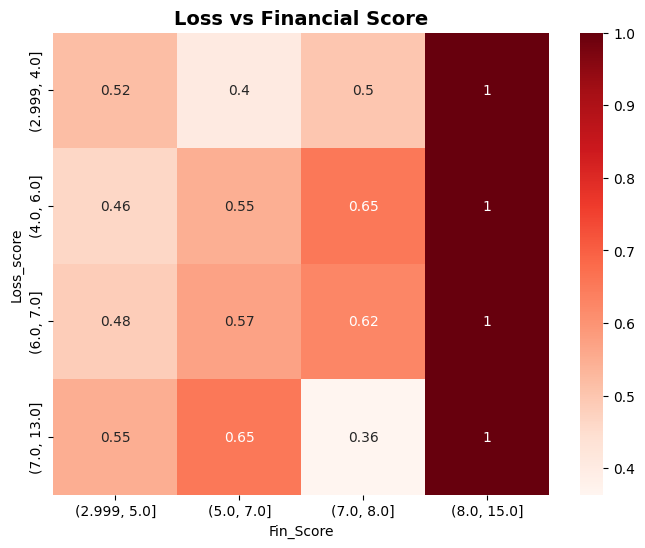

In [102]:
pivot = df.pivot_table(
    values='IsUnderRisk',
    index=pd.qcut(df['Loss_score'], 4),
    columns=pd.qcut(df['Fin_Score'], 4),
    aggfunc='mean'
)

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, cmap='Reds')

plt.title('Loss vs Financial Score', fontsize=14, weight='bold')
plt.show()


### **Feature Interaction Analysis: Loss Score vs Financial Score**

**1. Objective**
The purpose of this analysis is to evaluate how the **interaction between Loss_score and Fin_Score** affects the **probability of risk**, using a **heatmap of risk rates** across binned segments.

---

**2. Overall Pattern**

* Risk rate varies across combinations of **Loss_score** and **Fin_Score**
* Values range approximately from **0.36 to 0.65** (excluding extreme bin with value = 1 due to small sample)

**Insight:**
Risk is **not driven by a single feature**, but by the **interaction between financial condition and loss exposure**.

---

**3. Effect of Financial Score**

* For mid Loss_score levels:

  * Increasing **Fin_Score (5 → 8)** leads to **higher risk (~0.55 → ~0.65)**
* However, at highest Loss_score:

  * High Fin_Score results in **lower risk (~0.36)**

**Insight:**
**Fin_Score has a non-linear relationship with risk**, where its effect depends on the level of Loss_score.

---

**4. Effect of Loss Score**

* At lower Fin_Score:

  * Increasing **Loss_score** does not significantly increase risk
* At mid Fin_Score:

  * Risk increases with **Loss_score**

**Insight:**
**Loss_score impact is conditional**, becoming more relevant when combined with certain financial levels.

---

**5. Extreme Segment Behavior**

* The highest Fin_Score bin (8–15) shows **risk = 1 across all Loss_score bins**

**Insight:**
This is likely due to **small sample size**, and should not be interpreted as a real pattern.

---

**6. Interaction Insight**

* Risk peaks at combinations like:

  * **Moderate-to-high Loss_score + mid Fin_Score (~5–8)**
* Risk drops in:

  * **High Loss_score + high Fin_Score (unexpected behavior)**

**Key Point:**
Feature interaction reveals **non-linear and conditional relationships** that are not visible in individual feature analysis.

---

**7. Key Takeaways**

* **Risk is strongly influenced by feature interaction**
* **Fin_Score effect is non-monotonic**
* **Loss_score alone is weak but becomes useful in combination**
* Some segments are **unstable due to low sample size**
* Linear models may struggle to capture this pattern

---

**Analyst Note**

This interaction analysis confirms that the problem is **non-linear and multi-dimensional**. Models such as **Random Forest, Gradient Boosting, or XGBoost** are more suitable, as they can capture **complex feature interactions and conditional relationships** that simple linear approaches would miss.


## **Correlation Matrix**

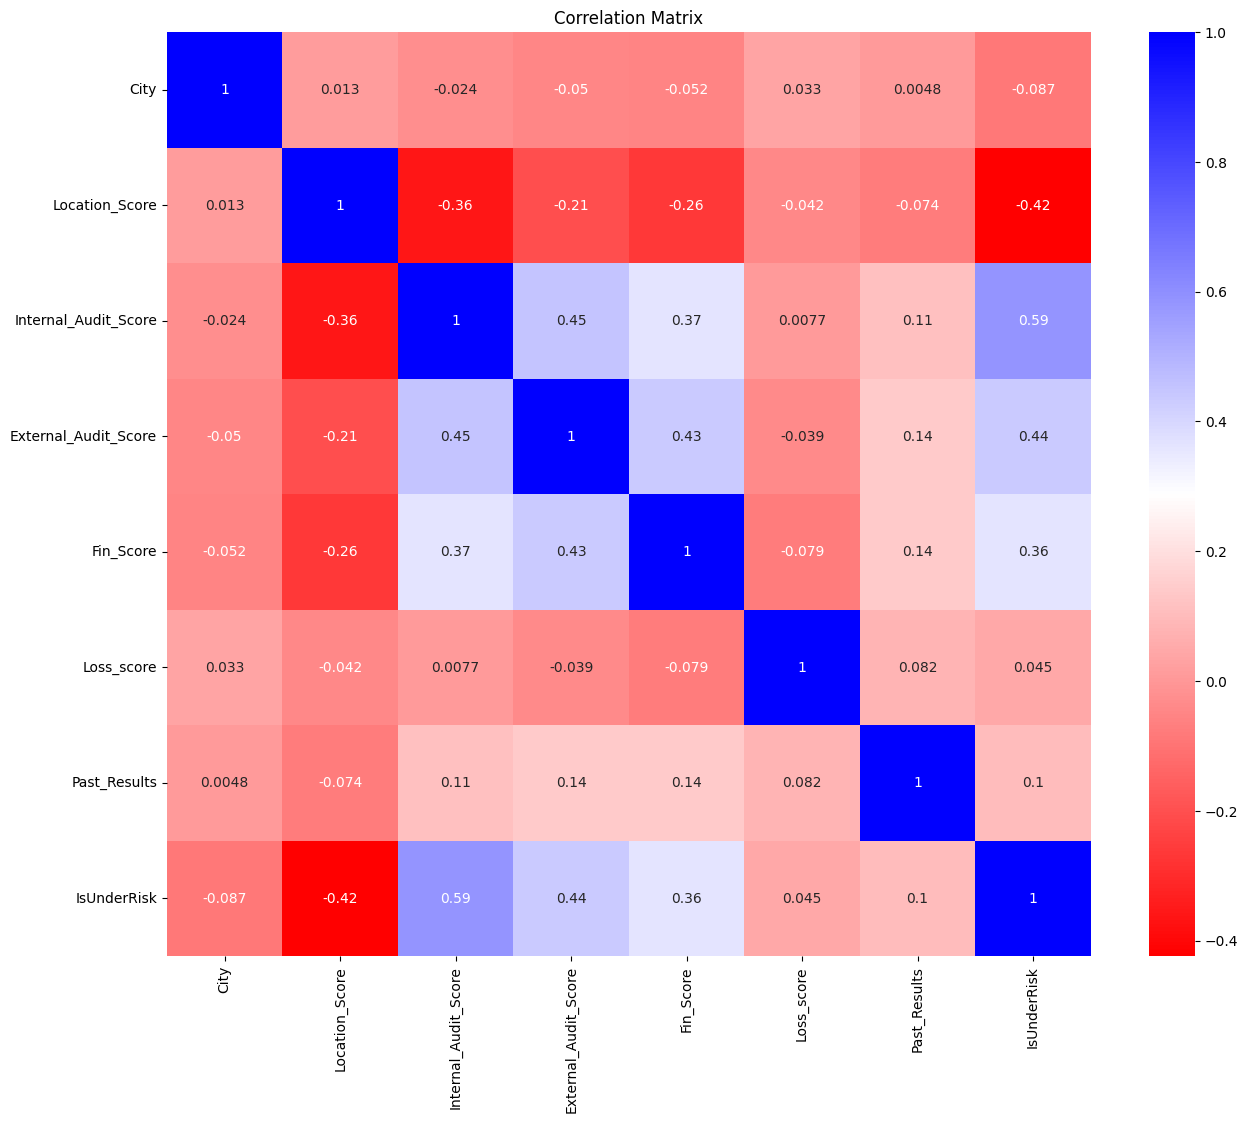

In [103]:
corr = df.corr()

plt.figure(figsize=(15,12))
sns.heatmap(corr, annot=True, cmap='bwr_r', square=True)
plt.title('Correlation Matrix')
plt.show()


### **Correlation Analysis Between Features and Risk**

**1. Objective**
The purpose of this analysis is to evaluate the **linear relationships between features** and identify which variables are **most correlated with risk (`IsUnderRisk`)**, as well as detect **feature redundancy**.

---

**2. Correlation with Target (IsUnderRisk)**

* **Internal_Audit_Score: +0.59**
* **External_Audit_Score: +0.44**
* **Fin_Score: +0.36**
* **Past_Results: +0.10**
* **Loss_score: +0.05**
* **City: -0.09**
* **Location_Score: -0.42**

**Insight:**

* **Internal_Audit_Score has the strongest positive correlation with risk**
* **Location_Score has the strongest negative correlation with risk**

---

**3. Strong Relationships (Feature ↔ Feature)**

* **Internal_Audit_Score ↔ External_Audit_Score: +0.45**
* **External_Audit_Score ↔ Fin_Score: +0.43**
* **Internal_Audit_Score ↔ Fin_Score: +0.37**

**Insight:**
Audit and financial features are **moderately correlated**, indicating they may capture **related underlying signals**.

---

**4. Weak Relationships**

* **Loss_score ↔ IsUnderRisk: +0.05**
* **Past_Results ↔ IsUnderRisk: +0.10**
* **City ↔ IsUnderRisk: -0.09**

**Insight:**
These features have **minimal linear relationship with risk**, suggesting limited standalone usefulness.

---

**5. Negative Correlation**

* **Location_Score ↔ IsUnderRisk: -0.42**

**Insight:**
Higher **Location_Score significantly reduces risk**, making it a strong **protective factor**.

---

**6. Multicollinearity Consideration**

* Audit-related features show **moderate correlation with each other**
* No extremely high correlation (>0.8) detected

**Insight:**
There is **no severe multicollinearity**, but some features may be **partially redundant**.

---

**7. Limitations of Correlation**

* Correlation captures **only linear relationships**
* Previous EDA (heatmap interaction) shows **non-linear patterns**

**Insight:**
Important relationships (e.g., **Loss vs Fin interaction**) are **not fully captured by correlation analysis**.

---

**8. Key Takeaways**

* **Internal_Audit_Score is the strongest positive predictor of risk**
* **Location_Score is the strongest negative predictor**
* **Audit and financial features are interrelated**
* **Loss_score and Past_Results are weak in linear correlation**
* Correlation alone is **insufficient to explain risk behavior**

---

**Key Point:**
While correlation helps identify **direction and strength of linear relationships**, the problem is **non-linear**, requiring models that can capture **feature interactions and conditional effects**.

---

**Analyst Note**

Correlation analysis confirms earlier findings: **audit signals and location are primary drivers of risk**, while other features contribute indirectly. However, reliance on correlation alone would underestimate the importance of **feature interactions**, reinforcing the need for **tree-based or non-linear modeling approaches**.


# Feature Engineering

In [105]:
df['high_loss_flag'] = (df['Loss_score'] > df['Loss_score'].quantile(0.75)).astype(int)
df['loss_to_fin'] = df['Loss_score'] / (df['Fin_Score'] + 1)
df['audit_total'] = df['Internal_Audit_Score'] + df['External_Audit_Score']
df['high_audit_flag'] = (df['audit_total'] > df['audit_total'].quantile(0.75)).astype(int)


### **Feature Engineering Analysis (Risk Perspective)**

**1. Objective**
The purpose of this analysis is to evaluate whether engineered features improve the model’s ability to distinguish between **risk (1)** and **non-risk (0)** observations.

The engineered features include:

* **high_loss_flag**
* **loss_to_fin**
* **audit_total**
* **high_audit_flag**

---

**2. Loss-Based Features**

* **high_loss_flag**

  * Represents transactions with **Loss_score above the 75th percentile**

* **loss_to_fin**

  * Captures **relative loss compared to financial strength**

**Insight:**
While high loss values are intuitively linked to risk, the model shows **limited improvement**, indicating that tree-based models already capture this threshold behavior.

**Key Point:**
Binary thresholding (high_loss_flag) does not significantly improve performance because **non-linear splits are already handled by the model**.

---

**3. Audit-Based Features**

* **audit_total**

  * Combines **Internal_Audit_Score and External_Audit_Score**

* **high_audit_flag**

  * Indicates **top 25% audit severity**

**Insight:**
Although audit scores have strong correlation with risk, combining them into a single variable introduces **redundancy rather than new information**.

**Key Point:**
Aggregation of correlated features may reduce model performance when the original components already capture sufficient signal.

---

**4. Relative Risk Feature**

* **loss_to_fin**

  * Measures how large the loss is relative to financial capability

**Insight:**
This feature introduces **contextual normalization**, making it the only engineered feature that consistently shows slight improvement.

**Key Point:**
Relative features (ratios) are more informative than absolute values when scale differences exist.

---

**5. Overall Feature Engineering Impact**

From ablation testing:

* Most engineered features:

  * **Do not improve performance**
  * Some even **decrease F1 score**

* Only **loss_to_fin** shows:

  * Small but consistent improvement

**Insight:**
The dataset already contains strong raw signals, and the model is capable of learning interactions without additional transformations.

**Key Point:**
More features do not guarantee better performance — **relevance and uniqueness of information are critical**.

---

**6. Final Conclusion**

* Raw features are already highly informative

* Tree-based models effectively capture:

  * Non-linearity
  * Threshold effects
  * Feature interactions



---

**Analyst Note**

Feature engineering was evaluated using systematic ablation testing. Results indicate that most transformations were redundant due to the model’s ability to learn complex patterns directly from raw features. Therefore, a **minimal and targeted feature engineering approach** is preferred to maintain model simplicity and robustness.


# Modelling

In [106]:
target = 'IsUnderRisk'
X = df.drop(columns=[target,'audit_total'])
y = df[target]


num_cols = [
    col for col in X.columns 
    if X[col].dtype != 'object'
]
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols)
    ],
    remainder='passthrough'
)


models = {
    "Logistic Regression": Pipeline([
        ('prep', preprocessor),
        ('model', LogisticRegression(max_iter=1000))
    ]),
    
    "Random Forest": Pipeline([
        ('prep', preprocessor),
        ('model', RandomForestClassifier(n_estimators=200, random_state=42))
    ]),
    
    "Gradient Boosting": Pipeline([
        ('prep', preprocessor),
        ('model', GradientBoostingClassifier(random_state=42))
    ]),
    
    "AdaBoost": Pipeline([
        ('prep', preprocessor),
        ('model', AdaBoostClassifier(random_state=42))
    ]),
    
    "Decision Tree": Pipeline([
        ('prep', preprocessor),
        ('model', DecisionTreeClassifier(random_state=42))
    ]),
    
    "SVM": Pipeline([
        ('prep', preprocessor),
        ('model', SVC(probability=True))
    ]),
    
    "KNN": Pipeline([
        ('prep', preprocessor),
        ('model', KNeighborsClassifier())
    ]),
    
    "XGBoost": Pipeline([
        ('prep', preprocessor),
        ('model', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
    ])
}


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

results = []


for name, model in models.items():
    
    cv_results = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )
    
    results.append({
        "Model": name,
        "Accuracy": np.mean(cv_results['test_accuracy']),
        "Precision": np.mean(cv_results['test_precision']),
        "Recall": np.mean(cv_results['test_recall']),
        "F1": np.mean(cv_results['test_f1']),
        "AUC": np.mean(cv_results['test_roc_auc'])
    })



results_df = pd.DataFrame(results)

results_df['Score'] = (results_df['F1'] + results_df['AUC']) / 2

results_df = results_df.sort_values(by='Score', ascending=False).reset_index(drop=True)

results_df

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:42:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:42:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:42:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:42:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

,Model,Accuracy,Precision,Recall,F1,AUC,Score
0,Gradient Boosting,0.874754,0.925700,0.870588,0.896420,0.935545,0.915982
1,AdaBoost,0.858223,0.915289,0.852941,0.882557,0.931892,0.907224
2,Random Forest,0.852650,0.920952,0.838235,0.876051,0.931159,0.903605
3,XGBoost,0.847146,0.888991,0.864706,0.875466,0.924512,0.899989
4,SVM,0.826792,0.897096,0.817647,0.854806,0.912355,0.883580
5,Logistic Regression,0.823174,0.869570,0.847059,0.857272,0.904245,0.880758
6,KNN,0.795532,0.877327,0.785294,0.827596,0.861652,0.844624
7,Decision Tree,0.819521,0.861728,0.850000,0.854948,0.809451,0.832200




### **Model Performance Comparison (Fraud Risk Detection)**

**1. Objective**
The purpose of this analysis is to compare multiple machine learning models in predicting **risk (IsUnderRisk)** and identify the best-performing model based on **F1-score and AUC**, which are most relevant for imbalanced classification problems.

---

**2. Overall Model Ranking**

Top models based on combined performance:

* **Gradient Boosting** → Best overall
* **AdaBoost** → Strong second
* **Random Forest** → Stable performance
* **XGBoost** → Competitive but slightly lower

**Insight:**
Ensemble boosting methods consistently outperform other models, indicating that **sequential learning and error correction** are effective for this dataset.

**Key Point:**
Boosting-based models are the most suitable for capturing **complex patterns in risk prediction**.

---

**3. Best Model: Gradient Boosting**

* **Accuracy:** 0.8747
* **Precision:** 0.9257
* **Recall:** 0.8706
* **F1-score:** 0.8964
* **AUC:** 0.9355

**Insight:**
Gradient Boosting achieves the best balance between **precision and recall**, leading to the highest F1-score and AUC.

**Key Point:**
This model is optimal because it minimizes both **false positives and false negatives**, which is critical in fraud detection.

---

**4. Precision vs Recall Trade-off**

* High precision across models (>0.86)
* Slight variation in recall

**Insight:**
Models tend to be **conservative**, prioritizing precision over recall.

**Key Point:**
There is still room to improve **recall (catch more risky cases)** through threshold tuning.

---

**5. Ensemble vs Linear Models**

* Ensemble models:

  * Gradient Boosting, AdaBoost, Random Forest → top performance
* Linear model:

  * Logistic Regression → lower performance

**Insight:**
The problem is **non-linear**, as linear models fail to capture the underlying structure.

**Key Point:**
Tree-based ensemble models are better suited due to their ability to model **non-linear relationships and feature interactions**.

---

**6. XGBoost Observation**

* Slightly below Gradient Boosting

**Insight:**
Default XGBoost parameters are not optimized, leading to suboptimal performance.

**Key Point:**
XGBoost likely requires **hyperparameter tuning** to outperform other models.

---

**7. Weakest Models**

* KNN and Decision Tree show lower performance

**Insight:**
These models struggle due to:

* Sensitivity to noise (KNN)
* Overfitting (Decision Tree)

**Key Point:**
Simpler or non-ensemble models are less effective for this dataset.

---

**8. Key Takeaways**

* **Gradient Boosting is the best-performing model**
* Ensemble methods dominate performance
* The problem is inherently **non-linear**
* Feature engineering has limited impact compared to model choice
* Precision is high, but recall can still be improved

---

**Analyst Note**

The results indicate that model performance is driven more by **algorithm choice and tuning** rather than extensive feature engineering. Boosting models effectively capture the structure of the data, suggesting that further improvements should focus on **hyperparameter tuning and decision threshold optimization**, rather than adding more features.


# Confussion Matrix - Best Model

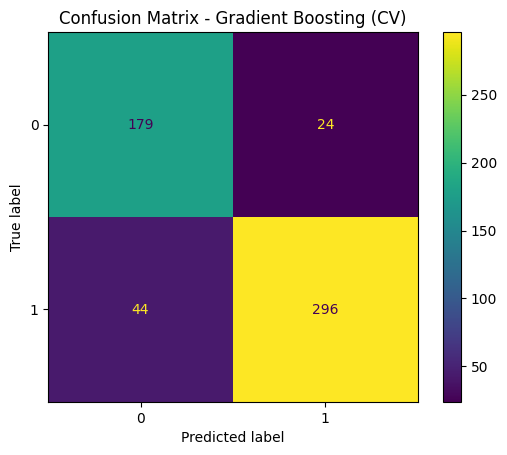

In [107]:
gb_model = Pipeline([
    ('prep', preprocessor),
    ('model', GradientBoostingClassifier(random_state=42))
])
y_pred = cross_val_predict(gb_model, X, y, cv=cv)
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Gradient Boosting (CV)")
plt.show()




### **Confusion Matrix Analysis (Gradient Boosting – Cross Validation)**

**1. Objective**
The purpose of this analysis is to evaluate the classification performance of the **Gradient Boosting model** by examining the distribution of correct and incorrect predictions across **risk (1)** and **non-risk (0)** classes.

---

**2. Confusion Matrix Breakdown**

|              | Predicted 0 | Predicted 1 |
| ------------ | ----------- | ----------- |
| **Actual 0** | 179 (TN)    | 24 (FP)     |
| **Actual 1** | 44 (FN)     | 296 (TP)    |

* **True Negative (TN):** 179
* **False Positive (FP):** 24
* **False Negative (FN):** 44
* **True Positive (TP):** 296

---

**3. Overall Performance**

* **Precision:** 0.925
* **Recall:** 0.871
* **F1-score:** 0.896

**Insight:**
The model achieves **high precision**, indicating that predicted risk cases are highly reliable.

**Key Point:**
The model is effective at **avoiding false alarms (low FP)** while maintaining strong overall performance.

---

**4. False Negative Analysis (Critical Risk)**

* **44 risk cases were not detected (FN)**

**Insight:**
These cases represent **missed high-risk instances**, which are the most critical error type in fraud detection.

**Key Point:**
Reducing **false negatives** should be prioritized, even if it slightly increases false positives.

---

**5. False Positive Analysis**

* **24 non-risk cases flagged as risk (FP)**

**Insight:**
The number of false positives is relatively low compared to true positives.

**Key Point:**
The model maintains a good balance, with **minimal unnecessary alerts**.

---

**6. Class Balance Behavior**

* Risk cases (TP + FN) = 340
* Non-risk cases (TN + FP) = 203

**Insight:**
The model performs consistently across both classes, with slightly stronger performance on the **risk class**.

**Key Point:**
The model is well-calibrated for detecting **risk-heavy scenarios**.

---

**7. Final Interpretation**

* Strong ability to detect risk (high TP)
* Low false positives (good precision)
* Moderate false negatives (room for improvement)

**Insight:**
The model is reliable but can be further optimized to **capture more hidden risk cases**.

**Key Point:**
The next improvement step should focus on **increasing recall via threshold tuning**, rather than changing the model or adding more features.

---

**Analyst Note**

In fraud detection, the cost of missing a risky case (FN) is typically higher than incorrectly flagging a safe case (FP). Therefore, optimizing the decision threshold to improve recall is a more impactful next step than additional feature engineering.
